# Inspect V-JEPA 2.1 Latents


This notebook loads `skate_latents.npy` / `skate_latents.metadata.json`, summarizes the tensor, and visualizes the latent grid in a few useful ways.


It assumes the extracted tensor has shape `[batch, time, height, width, embed_dim]`, which for your run is `[1, 8, 16, 16, 1024]`.

In [75]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
LATENT_NPY = ROOT / "skate_latents_768.npy"
LATENT_PT = ROOT / "skate_latents_768.pt"
METADATA_PATH = ROOT / "skate_latents_768.metadata.json"

def load_latents() -> tuple[np.ndarray, dict]:
    if LATENT_NPY.exists():
        latents = np.load(LATENT_NPY)
    elif LATENT_PT.exists():
        latents = torch.load(LATENT_PT, map_location="cpu").numpy()
    else:
        raise FileNotFoundError("Could not find `skate_latents.npy` or `skate_latents.pt` in the current directory.")

    if not METADATA_PATH.exists():
        raise FileNotFoundError("Could not find `skate_latents.metadata.json` in the current directory.")


    metadata = json.loads(METADATA_PATH.read_text())
    return latents, metadata

def flatten_latents(latents: np.ndarray) -> np.ndarray:
    return latents.reshape(-1, latents.shape[-1])


# def minmax_scale(values: np.ndarray) -> np.ndarray:
#     mins = values.min(axis=0, keepdims=True)
#     maxs = values.max(axis=0, keepdims=True)
#     return (values - mins) / np.maximum(maxs - mins, 1e-12)

def minmax_scale(values: np.ndarray, p_min=2.0, p_max=98.0) -> np.ndarray:
    mins = np.percentile(values, p_min, axis=0, keepdims=True)
    maxs = np.percentile(values, p_max, axis=0, keepdims=True)
    scaled = (values - mins) / np.maximum(maxs - mins, 1e-12)
    return np.clip(scaled, 0.0, 1.0)


latents, metadata = load_latents()
_, time_steps, grid_h, grid_w, _ = latents.shape

features = flatten_latents(latents)
features.shape

(11520, 1024)

PCA XYZ shape: (11520, 3)
PCA RGB shape: (11520, 3)
PCA intensity shape: (11520,)


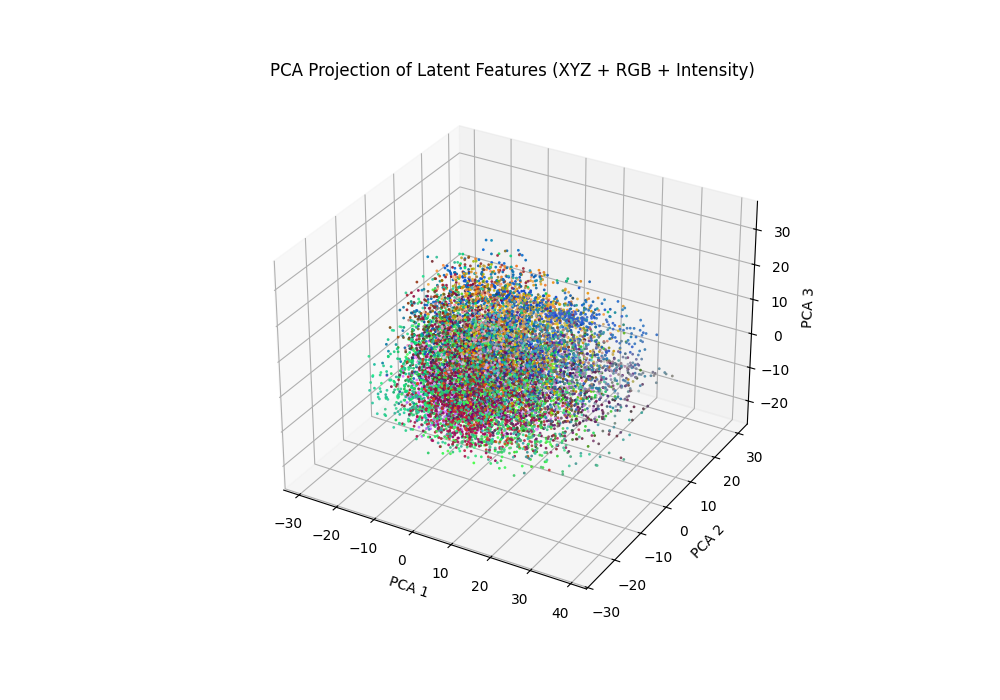

In [86]:
%matplotlib ipympl

import cv2
from IPython.display import Video, display

def pca_project(features: np.ndarray, n_components: int = 3) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    centered = features - features.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vt[:n_components].T
    explained = (s[:n_components] ** 2) / np.maximum((s ** 2).sum(), 1e-12)
    return coords, vt[:n_components], explained

pca_projection, _, explained_all = pca_project(features, n_components=7)

coords = pca_projection[:, 3:6]
pca_xyz = coords
pca_rgb = minmax_scale(pca_projection[:, :3])
pca_intensity = minmax_scale(pca_projection[:, 6:7]).squeeze(-1)
pca_rgba = np.concatenate([pca_rgb, pca_intensity[:, None]], axis=1)

explained = explained_all[:3]
rgb_video = (pca_rgb * pca_intensity[:, None]).reshape(time_steps, grid_h, grid_w, 3)
pca_xyz_video = pca_xyz.reshape(time_steps, grid_h, grid_w, 3)

print("PCA XYZ shape:", pca_xyz.shape)
print("PCA RGB shape:", pca_rgb.shape)
print("PCA intensity shape:", pca_intensity.shape)
# plot the first 3 PCA dimensions in 3D, and color each point using PCA dims 4-6 with PCA dim 7 as intensity

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_xyz[:, 0],
    pca_xyz[:, 1],
    pca_xyz[:, 2],
    c=pca_rgba,
    s=4,
    alpha=0.9,
    depthshade=False,
    linewidths=0,
 )
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('PCA Projection of Latent Features (XYZ + RGB + Intensity)')
plt.show()

In [77]:


target_resolution = int(metadata.get("crop_size", 384))
video_fps = float(metadata.get("video_metadata", {}).get("fps", 6.0))
pca_output_filename = ROOT / "latent_space_pca_smooth_384.mp4"
side_by_side_filename = ROOT / "latent_space_side_by_side_384.mp4"

frame_indices = np.asarray(metadata.get("frame_indices", list(range(time_steps))), dtype=int)
frame_groups = np.array_split(frame_indices, time_steps)
aligned_frame_indices = [int(group[len(group) // 2]) for group in frame_groups]
duplication_factor = max(1, len(frame_indices) // max(1, time_steps))

source_video_path = Path(metadata["video_path"] if "video_path" in metadata else "")
if not source_video_path.exists():
    raise FileNotFoundError(f"Could not find source video at {source_video_path}")

def center_crop_to_square(image_rgb: np.ndarray) -> np.ndarray:
    height, width = image_rgb.shape[:2]
    crop_size = min(height, width)
    top = (height - crop_size) // 2
    left = (width - crop_size) // 2
    return image_rgb[top:top + crop_size, left:left + crop_size]

def make_labeled_panel(image_rgb: np.ndarray, title: str, subtitle: str, crop_to_square: bool = False) -> np.ndarray:
    if crop_to_square:
        image_rgb = center_crop_to_square(image_rgb)
    panel = cv2.resize(image_rgb, (target_resolution, target_resolution), interpolation=cv2.INTER_CUBIC)
    panel_bgr = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
    panel_bgr = cv2.copyMakeBorder(panel_bgr, 48, 12, 12, 12, cv2.BORDER_CONSTANT, value=(18, 18, 18))
    cv2.putText(panel_bgr, title, (16, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(panel_bgr, subtitle, (16, panel_bgr.shape[0] - 14), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (210, 210, 210), 1, cv2.LINE_AA)
    return panel_bgr

cap = cv2.VideoCapture(str(source_video_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open source video {source_video_path}")

single_frame_size = (target_resolution, target_resolution)
panel_width = target_resolution + 24
panel_height = target_resolution + 60
gap = 16
side_by_side_size = (panel_width * 2 + gap * 3, panel_height + 24)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
pca_writer = cv2.VideoWriter(str(pca_output_filename), fourcc, video_fps, single_frame_size)
comparison_writer = cv2.VideoWriter(str(side_by_side_filename), fourcc, video_fps, side_by_side_size)

if not pca_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {pca_output_filename}")
if not comparison_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {side_by_side_filename}")

for time_index, (pca_frame, frame_number) in enumerate(zip(rgb_video, aligned_frame_indices)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, source_bgr = cap.read()
    if not ok:
        source_bgr = np.zeros((target_resolution, target_resolution, 3), dtype=np.uint8)
    source_rgb = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB)

    pca_rgb = (np.clip(pca_frame, 0.0, 1.0) * 255).astype(np.uint8)
    pca_smooth_rgb = cv2.resize(pca_rgb, single_frame_size, interpolation=cv2.INTER_CUBIC)
    pca_bgr = cv2.cvtColor(pca_smooth_rgb, cv2.COLOR_RGB2BGR)

    source_panel = make_labeled_panel(source_rgb, "Input frame", f"frame={frame_number}", crop_to_square=True)
    pca_panel = make_labeled_panel(pca_rgb, "Latent PCA", f"t={time_index}")

    comparison_frame = np.full((side_by_side_size[1], side_by_side_size[0], 3), 12, dtype=np.uint8)
    left_start = gap
    right_start = gap * 2 + panel_width
    comparison_frame[12:12 + panel_height, left_start:left_start + panel_width] = source_panel
    comparison_frame[12:12 + panel_height, right_start:right_start + panel_width] = pca_panel
    cv2.putText(comparison_frame, "Original vs. latent-space PCA", (18, side_by_side_size[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

    for _ in range(duplication_factor):
        pca_writer.write(pca_bgr)
        comparison_writer.write(comparison_frame)

cap.release()
pca_writer.release()
comparison_writer.release()

print(f"Saved smooth PCA video to: {pca_output_filename}")
print(f"Saved side-by-side video to: {side_by_side_filename}")
print(f"PCA resolution: {single_frame_size[0]}x{single_frame_size[1]}")
print(f"Side-by-side resolution: {side_by_side_size[0]}x{side_by_side_size[1]}")
print("Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.")
print(f"Each latent timestep is duplicated {duplication_factor}x to preserve the original clip timing.")
print("Explained variance:", ", ".join(f"PC{i + 1}={value:.4f}" for i, value in enumerate(explained)))

display(Video(str(side_by_side_filename), embed=True))

Saved smooth PCA video to: /Users/pishty/ws/vjepa2.1/latent_space_pca_smooth_384.mp4
Saved side-by-side video to: /Users/pishty/ws/vjepa2.1/latent_space_side_by_side_384.mp4
PCA resolution: 768x768
Side-by-side resolution: 1632x852
Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.
Each latent timestep is duplicated 2x to preserve the original clip timing.
Explained variance: PC1=0.0986, PC2=0.0824, PC3=0.0606


## PCA pattern plots

These plots turn the PCA coordinates into time-series views so you can spot trends, changes, and repeating structure across latent timesteps.

/Users/pishty/ws/vjepa2.1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP XYZ shape: (11520, 3)
UMAP RGB shape: (11520, 3)
UMAP intensity shape: (11520,)


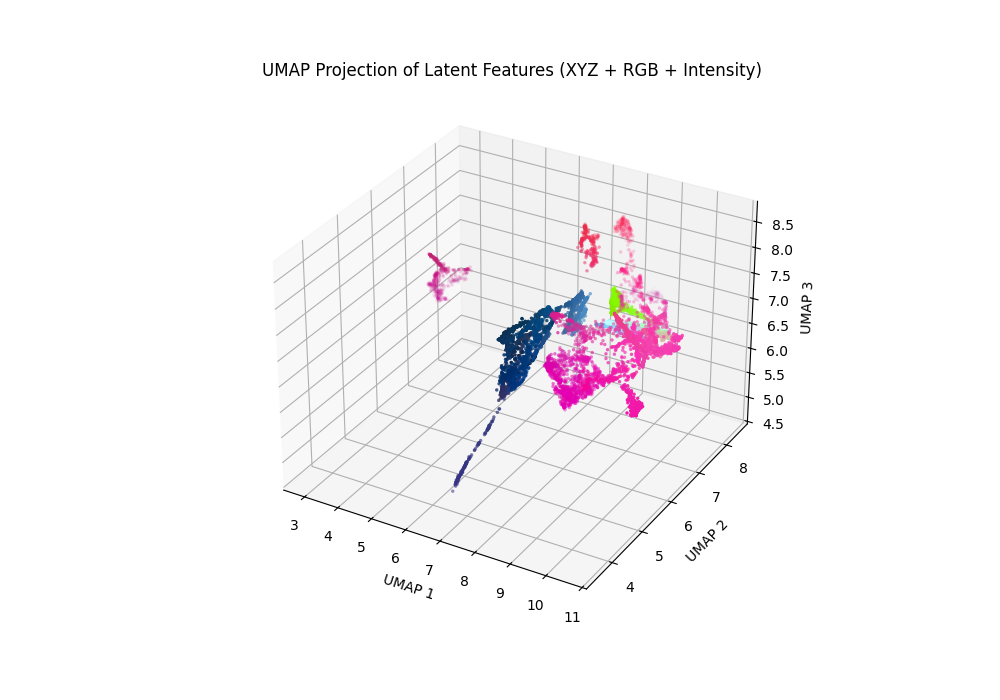

In [84]:
def umap_project(features: np.ndarray, n_components: int = 3) -> np.ndarray:
    import umap
    reducer = umap.UMAP(n_components=n_components, random_state=0)
    return reducer.fit_transform(features)

umap_projection = umap_project(features, n_components=7)
umap_xyz = umap_projection[:, 3:6]
umap_rgb = minmax_scale(umap_projection[:, :3])
umap_intensity = minmax_scale(umap_projection[:, 6:7]).squeeze(-1)
umap_rgba = np.concatenate([umap_rgb, umap_intensity[:, None]], axis=1)

umap_xyz_video = umap_xyz.reshape(time_steps, grid_h, grid_w, 3)
umap_rgb_video = (umap_rgb * umap_intensity[:, None]).reshape(time_steps, grid_h, grid_w, 3)

print("UMAP XYZ shape:", umap_xyz.shape)
print("UMAP RGB shape:", umap_rgb.shape)
print("UMAP intensity shape:", umap_intensity.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    umap_xyz[:, 0],
    umap_xyz[:, 1],
    umap_xyz[:, 2],
    c=umap_rgba,
    s=6,
    depthshade=False,
    linewidths=0,
)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
ax.set_title("UMAP Projection of Latent Features (XYZ + RGB + Intensity)")
plt.show()

In [85]:
import os
from pathlib import Path

import cv2
import numpy as np
from IPython.display import Video, display

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

target_resolution = int(metadata.get("crop_size", 384))
video_fps = float(metadata.get("video_metadata", {}).get("fps", 6.0))
umap_output_filename = ROOT / "latent_space_umap_384.mp4"
umap_side_by_side_filename = ROOT / "latent_space_umap_side_by_side_384.mp4"

frame_indices = np.asarray(metadata.get("frame_indices", list(range(time_steps))), dtype=int)
frame_groups = np.array_split(frame_indices, time_steps)
aligned_frame_indices = [int(group[len(group) // 2]) for group in frame_groups]
duplication_factor = max(1, len(frame_indices) // max(1, time_steps))

source_video_path = Path(metadata.get("video_path", ""))
if not source_video_path.exists():
    raise FileNotFoundError(f"Could not find source video at {source_video_path}")

def center_crop_to_square(image_rgb: np.ndarray) -> np.ndarray:
    height, width = image_rgb.shape[:2]
    crop_size = min(height, width)
    top = (height - crop_size) // 2
    left = (width - crop_size) // 2
    return image_rgb[top:top + crop_size, left:left + crop_size]

def make_labeled_panel(
    image_rgb: np.ndarray,
    title: str,
    subtitle: str,
    crop_to_square: bool = False,
    interpolation: int = cv2.INTER_LINEAR,
 ) -> np.ndarray:
    if crop_to_square:
        image_rgb = center_crop_to_square(image_rgb)
    panel = cv2.resize(image_rgb, (target_resolution, target_resolution), interpolation=interpolation)
    panel_bgr = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
    panel_bgr = cv2.copyMakeBorder(
        panel_bgr,
        48,
        12,
        12,
        12,
        cv2.BORDER_CONSTANT,
        value=(18, 18, 18),
    )
    cv2.putText(panel_bgr, title, (16, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(
        panel_bgr,
        subtitle,
        (16, panel_bgr.shape[0] - 14),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (210, 210, 210),
        1,
        cv2.LINE_AA,
    )
    return panel_bgr

cap = cv2.VideoCapture(str(source_video_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open source video {source_video_path}")

single_frame_size = (target_resolution, target_resolution)
panel_width = target_resolution + 24
panel_height = target_resolution + 60
gap = 16
side_by_side_size = (panel_width * 2 + gap * 3, panel_height + 24)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
umap_writer = cv2.VideoWriter(str(umap_output_filename), fourcc, video_fps, single_frame_size)
comparison_writer = cv2.VideoWriter(
    str(umap_side_by_side_filename),
    fourcc,
    video_fps,
    side_by_side_size,
 )

if not umap_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {umap_output_filename}")
if not comparison_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {umap_side_by_side_filename}")

for time_index, (umap_frame, frame_number) in enumerate(zip(umap_rgb_video, aligned_frame_indices)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, source_bgr = cap.read()
    if not ok:
        source_bgr = np.zeros((target_resolution, target_resolution, 3), dtype=np.uint8)
    source_rgb = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB)

    umap_rgb_uint8 = (np.clip(umap_frame, 0.0, 1.0) * 255).astype(np.uint8)
    umap_smooth_rgb = cv2.resize(umap_rgb_uint8, single_frame_size, interpolation=cv2.INTER_NEAREST)
    umap_bgr = cv2.cvtColor(umap_smooth_rgb, cv2.COLOR_RGB2BGR)

    source_panel = make_labeled_panel(
        source_rgb,
        "Input frame",
        f"frame={frame_number}",
        crop_to_square=True,
        interpolation=cv2.INTER_CUBIC,
    )
    umap_panel = make_labeled_panel(
        umap_rgb_uint8,
        "Latent UMAP",
        f"t={time_index}",
        interpolation=cv2.INTER_NEAREST,
    )

    comparison_frame = np.full((side_by_side_size[1], side_by_side_size[0], 3), 12, dtype=np.uint8)
    left_start = gap
    right_start = gap * 2 + panel_width
    comparison_frame[12:12 + panel_height, left_start:left_start + panel_width] = source_panel
    comparison_frame[12:12 + panel_height, right_start:right_start + panel_width] = umap_panel
    cv2.putText(
        comparison_frame,
        "Original vs. latent-space UMAP",
        (18, side_by_side_size[1] - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    for _ in range(duplication_factor):
        umap_writer.write(umap_bgr)
        comparison_writer.write(comparison_frame)

cap.release()
umap_writer.release()
comparison_writer.release()

print(f"Saved smooth UMAP video to: {umap_output_filename}")
print(f"Saved side-by-side UMAP video to: {umap_side_by_side_filename}")
print(f"UMAP resolution: {single_frame_size[0]}x{single_frame_size[1]}")
print(f"Side-by-side resolution: {side_by_side_size[0]}x{side_by_side_size[1]}")
print("Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.")
print(f"Each latent timestep is duplicated {duplication_factor}x to preserve the original clip timing.")

display(Video(str(umap_side_by_side_filename), embed=True))

Saved smooth UMAP video to: /Users/pishty/ws/vjepa2.1/latent_space_umap_384.mp4
Saved side-by-side UMAP video to: /Users/pishty/ws/vjepa2.1/latent_space_umap_side_by_side_384.mp4
UMAP resolution: 768x768
Side-by-side resolution: 1632x852
Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.
Each latent timestep is duplicated 2x to preserve the original clip timing.
